# K09_01 - Keras MLP mit zwei Hidden Layers

## Lernziele
Nach diesem Notebook koennen Sie:
- ein tieferes MLP mit Keras aufbauen
- den Unterschied zwischen einem kleinen und einem tieferen Netz
  **quantitativ** (Parameteranzahl) und **qualitativ** (Lernkurven) einordnen
- den Begriff **Modellkapazitaet** erklaeren
- Lernkurven (Train UND Val) korrekt lesen und interpretieren
- Overfitting an den Lernkurven erkennen
- einschaetzen, wann mehr Tiefe hilft und wann nicht


## Didaktischer Fokus

Leitfrage:
> Was aendert sich, wenn wir statt eines kleinen Netzes ein Modell
> mit zwei Hidden Layers verwenden?

Wir beantworten diese Frage auf drei Ebenen:
1. **Architektur:** Wie viele Parameter hat jedes Modell?
2. **Training:** Wie entwickeln sich Train- und Val-Kurven?
3. **Ergebnis:** Unterscheidet sich die finale Test-Accuracy?

### Warum nicht Iris?

Iris hat nur 150 Samples. Das ist fuer diesen Vergleich zu wenig:
- Das Validierungsset wird so klein (~24 Samples), dass die Kurven
  treppenartig springen statt glatt zu verlaufen.
- Iris ist so einfach, dass das kleine Netz bereits alles loest.
  Das tiefe Netz hat keinen echten Vorteil – der Vergleich wird sinnlos.

Wir verwenden stattdessen einen **synthetischen Datensatz** mit 2000 Samples
und 20 Features. Das gibt:
- genuegend Daten fuer glatte, lesbare Lernkurven
- eine Aufgabe, die komplex genug ist damit das tiefe Netz einen echten Vorteil zeigt
- ein sichtbares Overfitting-Signal wenn das Modell zu gross ist


## Imports und Reproduzierbarkeit


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow import keras
from tensorflow.keras import layers

import random
random.seed(42)

print('Alle Bibliotheken geladen.')
print(f'TensorFlow-Version: {tf.__version__}')


Alle Bibliotheken geladen.
TensorFlow-Version: 2.20.0


## 1. Synthetischen Datensatz erstellen

`make_classification` erzeugt einen kontrollierten Klassifikationsdatensatz.
Die Parameter bestimmen, wie schwierig die Aufgabe ist:

| Parameter | Bedeutung | Wert hier |
|---|---|---|
| `n_samples` | Anzahl Datenpunkte | 2000 |
| `n_features` | Anzahl Features insgesamt | 20 |
| `n_informative` | Davon wirklich relevante | 10 |
| `n_redundant` | Lineare Kombinationen | 5 |
| `n_classes` | Anzahl Klassen | 3 |
| `n_clusters_per_class` | Struktur pro Klasse | 2 |

Die 10 nicht-informativen Features und 2 Cluster pro Klasse machen die Aufgabe
schwierig genug, damit das tiefe Netz einen echten Vorteil gegenueber dem kleinen hat.


In [ ]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=3,
    n_clusters_per_class=2, # jede Klasse hat zwei räumlich getrennte Cluster, insgesamt also 6 Cluster
    random_state=42
)

# One-Hot-Encoding
y_cat = keras.utils.to_categorical(y, num_classes=3)
class_names = ['Klasse 0', 'Klasse 1', 'Klasse 2']

# Klassenverteilung pruefen
unique, counts = np.unique(y, return_counts=True)
print('Datensatz erstellt:')
print(f'  Shape X: {X.shape}')
print(f'  Shape y: {y.shape}')
print('  Klassenverteilung:')
for klasse, anzahl in zip(unique, counts):
    balken = '█' * (anzahl // 20)
    print(f'    Klasse {klasse}: {anzahl:4d} Samples  {balken}')


Datensatz erstellt:
  Shape X: (2000, 20)
  Shape y: (2000,)
  Klassenverteilung:
    Klasse 0:  662 Samples  █████████████████████████████████
    Klasse 1:  670 Samples  █████████████████████████████████
    Klasse 2:  668 Samples  █████████████████████████████████


## 2. Daten aufteilen und skalieren

Mit 2000 Samples reicht ein einfacher Train/Test-Split.
Das Validierungsset wird direkt in `model.fit()` via `validation_split=0.2`
aus den Trainingsdaten erzeugt.

```
2000 Samples
  x 80% Train+Val = 1600 Trainingsdaten
    x 20% Val     =  320 Validierungsdaten  <- genuegend fuer glatte Kurven
    x 80% Train   = 1280 Trainingsdaten
  x 20% Test      =  400 Testdaten
```

320 Validierungssamples statt 24 bei Iris:
1 Fehler = 0.3% statt 4.2% Accuracy-Sprung -> glatte Kurven.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Trainingsdaten (inkl. Val): {X_train_scaled.shape}')
print(f'Testdaten:                  {X_test_scaled.shape}')
print(f'Validierungsdaten (20% v. Train via validation_split): ~{int(X_train.shape[0]*0.2)} Samples')


Trainingsdaten (inkl. Val): (1600, 20)
Testdaten:                  (400, 20)
Validierungsdaten (20% v. Train via validation_split): ~320 Samples


## 3. Konzept: Warum zwei Hidden Layers?

Jede versteckte Schicht kann andere **Abstraktionsebenen** lernen:

```
1 Hidden Layer:  lernt einfache Merkmalskombinationen
                 z. B. 'Feature 3 gross UND Feature 7 klein -> Klasse 1'

2 Hidden Layer:  kann Merkmale hierarchisch kombinieren
                 Schicht 1: lernt elementare Muster aus den 20 Features
                 Schicht 2: kombiniert diese Muster zu komplexeren Strukturen
```

**Modellkapazitaet** = wie viele Muster ein Netz maximal lernen kann.
Sie wird hauptsaechlich durch die Anzahl der Parameter bestimmt.

Bei 20 Features und 3 Klassen mit je 2 Clustern ist die Aufgabe
komplex genug, dass mehr Kapazitaet tatsaechlich hilft.


## 4. Zwei Modelle definieren


In [ ]:
# Modell A: kleines Netz - 1 Hidden Layer
model_small = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3,  activation='softmax')
], name='kleines_Netz')

model_small.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Modell B: tiefes Netz - 2 Hidden Layers
model_deep = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3,  activation='softmax')
], name='tiefes_Netz')

model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('=== Kleines Netz ===')
model_small.summary()
print()
print('=== Tiefes Netz ===')
model_deep.summary()


=== Kleines Netz ===


Model: "kleines_Netz"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

...

Model: "tiefes_Netz"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,523 (13.76 KB)

 Trainable params: 3,523 (13.76 KB)

 Non-trainable params: 0 (0.00 B)

### Parameteranzahl im Vergleich

```
Kleines Netz (Input: 20 Features):
  Dense(16):  20 x 16 + 16 Bias  =   336 Parameter
  Dense(3):   16 x  3 +  3 Bias  =    51 Parameter
  Gesamt:                             387 Parameter

Tiefes Netz (Input: 20 Features):
  Dense(64):  20 x 64 + 64 Bias  =  1344 Parameter
  Dense(32):  64 x 32 + 32 Bias  =  2080 Parameter
  Dense(3):   32 x  3 +  3 Bias  =    99 Parameter
  Gesamt:                           3523 Parameter
```

Das tiefe Netz hat **~9x mehr Parameter** – deutlich mehr Modellkapazitaet.
Bei 20 Features und einer komplexen Aufgabe sollte das einen messbaren Unterschied machen.

> **Frage zum Nachdenken:** Fuehren 9x mehr Parameter automatisch
> zu besserer Accuracy? Die Lernkurven werden es zeigen.


## 5. Beide Modelle trainieren

Beide Modelle trainieren mit identischen Hyperparametern.
`validation_split=0.2` nimmt die letzten 20% der Trainingsdaten als Val.
Da die Daten vorher per `train_test_split` gemischt wurden, ist das ausreichend.


In [ ]:
EPOCHS     = 100
BATCH_SIZE = 32

history_small = model_small.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2
)

history_deep = model_deep.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2
)

print(f'Training abgeschlossen: {EPOCHS} Epochen, batch_size={BATCH_SIZE}')


Epoch 1/100
40/40 - 1s - 29ms/step - accuracy: 0.4492 - loss: 1.0933 - val_accuracy: 0.4750 - val_loss: 1.0437
Epoch 2/100
40/40 - 0s - 4ms/step - accuracy: 0.5461 - loss: 0.9875 - val_accuracy: 0.5781 - val_loss: 0.9540
Epoch 3/100
40/40 - 0s - 4ms/step - accuracy: 0.5938 - loss: 0.9202 - val_accuracy: 0.6156 - val_loss: 0.8926
Epoch 4/100
40/40 - 0s - 8ms/step - accuracy: 0.6297 - loss: 0.8703 - val_accuracy: 0.6281 - val_loss: 0.8460
Epoch 5/100
40/40 - 0s - 4ms/step - accuracy: 0.6523 - loss: 0.8296 - val_accuracy: 0.6469 - val_loss: 0.8085
Epoch 6/100
40/40 - 0s - 4ms/step - accuracy: 0.6648 - loss: 0.7948 - val_accuracy: 0.6781 - val_loss: 0.7773
Epoch 7/100
40/40 - 0s - 4ms/step - accuracy: 0.6844 - loss: 0.7643 - val_accuracy: 0.6906 - val_loss: 0.7522
Epoch 8/100
40/40 - 0s - 4ms/step - accuracy: 0.6992 - loss: 0.7377 - val_accuracy: 0.7000 - val_loss: 0.7307
Epoch 9/100
40/40 - 0s - 4ms/step - accuracy: 0.7086 - loss: 0.7137 - val_accuracy: 0.7094 - val_loss: 0.7119
Epoch 10/

## 6. Lernkurven vergleichen (Train UND Val)

**Legende:**
- **Blau** = kleines Netz | **Orange** = tiefes Netz
- **Gestrichelt** = Trainingsdaten | **Durchgezogen** = Validierungsdaten

**Worauf achten?**

| Muster | Diagnose |
|---|---|
| Train und Val sinken parallel | Gute Generalisierung |
| Grosser Abstand Train vs. Val | Overfitting |
| Val-Loss steigt, Train-Loss sinkt | Klares Overfitting-Signal |
| Beide Kurven stagnieren frueh | Underfitting / zu wenig Kapazitaet |


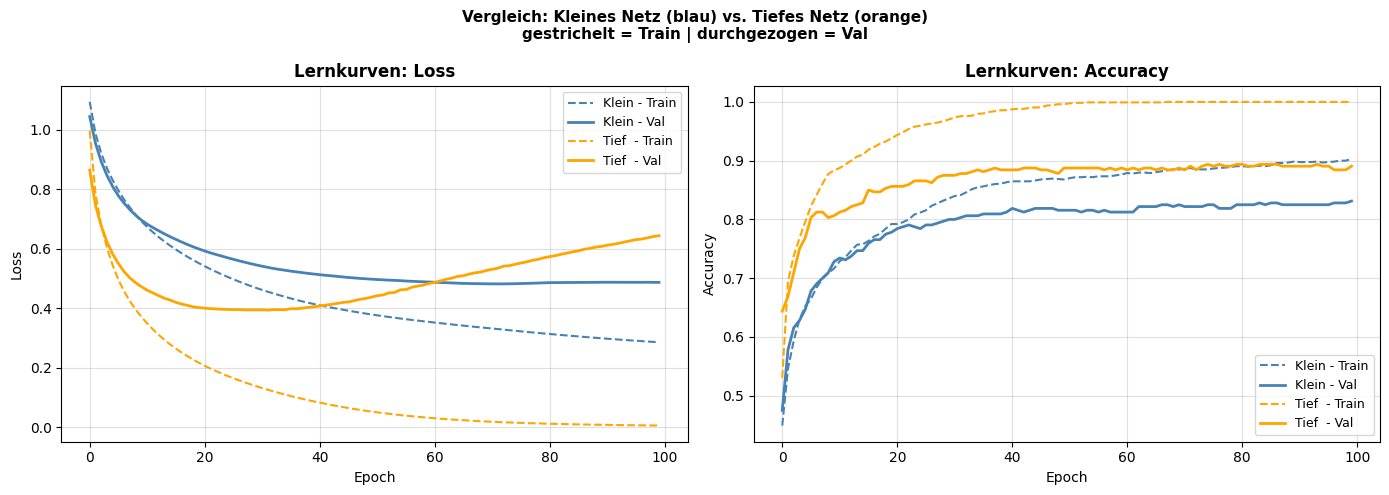

In [ ]:
hist_small = pd.DataFrame(history_small.history)
hist_deep  = pd.DataFrame(history_deep.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(hist_small['loss'],     color='steelblue', linestyle='--', linewidth=1.5, label='Klein - Train')
axes[0].plot(hist_small['val_loss'], color='steelblue', linestyle='-',  linewidth=2,   label='Klein - Val')
axes[0].plot(hist_deep['loss'],      color='orange',    linestyle='--', linewidth=1.5, label='Tief  - Train')
axes[0].plot(hist_deep['val_loss'],  color='orange',    linestyle='-',  linewidth=2,   label='Tief  - Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Lernkurven: Loss', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# --- Accuracy ---
axes[1].plot(hist_small['accuracy'],     color='steelblue', linestyle='--', linewidth=1.5, label='Klein - Train')
axes[1].plot(hist_small['val_accuracy'], color='steelblue', linestyle='-',  linewidth=2,   label='Klein - Val')
axes[1].plot(hist_deep['accuracy'],      color='orange',    linestyle='--', linewidth=1.5, label='Tief  - Train')
axes[1].plot(hist_deep['val_accuracy'],  color='orange',    linestyle='-',  linewidth=2,   label='Tief  - Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Lernkurven: Accuracy', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.suptitle(
    'Vergleich: Kleines Netz (blau) vs. Tiefes Netz (orange)\n'
    'gestrichelt = Train | durchgezogen = Val',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()


## Analyse der Ergebnisse

---

### Was die Kurven zeigen

**Tiefes Netz (orange) — klassisches Overfitting:**
```
Train-Accuracy:  → 100%    (orange gestrichelt steigt auf 1.0)
Val-Accuracy:    →  83%    (orange durchgezogen stagniert)
Train-Loss:      →   ~0    (sinkt gegen 0)
Val-Loss:        →  0.9+   (steigt ab Epoche ~15 stark an)
```
Das ist ein **Lehrbuchbeispiel für Overfitting** — Train-Loss sinkt auf fast 0, Val-Loss steigt gleichzeitig stark. Das Modell lernt die Trainingsdaten auswendig.

**Kleines Netz (blau) — stabile Generalisierung:**
```
Train-Accuracy:  →  88%    (blau gestrichelt)
Val-Accuracy:    →  81%    (blau durchgezogen, stabil)
Train-Loss:      →  0.25   (sinkt noch leicht)
Val-Loss:        →  0.50   (stabil, kein Anstieg)
```
Kein Overfitting — Train und Val laufen parallel. Aber: das Modell hat nicht die Kapazität die volle Struktur der Daten zu lernen.



## 7. Testdaten-Evaluation


                       Modell  Parameter  Test-Accuracy
Kleines Netz (1 Hidden Layer)        387         0.8150
Tiefes Netz (2 Hidden Layers)       3523         0.8325


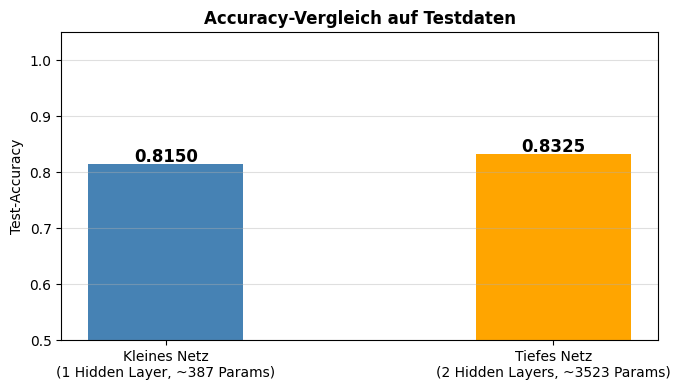

In [ ]:
y_pred_small = np.argmax(model_small.predict(X_test_scaled, verbose=0), axis=1)
y_pred_deep  = np.argmax(model_deep.predict(X_test_scaled,  verbose=0), axis=1)
y_true       = np.argmax(y_test, axis=1)

acc_small = accuracy_score(y_true, y_pred_small)
acc_deep  = accuracy_score(y_true, y_pred_deep)

results = pd.DataFrame({
    'Modell':        ['Kleines Netz (1 Hidden Layer)', 'Tiefes Netz (2 Hidden Layers)'],
    'Parameter':     [model_small.count_params(), model_deep.count_params()],
    'Test-Accuracy': [round(acc_small, 4), round(acc_deep, 4)]
})
print(results.to_string(index=False))

# Barplot
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Kleines Netz\n(1 Hidden Layer, ~387 Params)',
     'Tiefes Netz\n(2 Hidden Layers, ~3523 Params)'],
    [acc_small, acc_deep],
    color=['steelblue', 'orange'], width=0.4
)
for bar, acc in zip(bars, [acc_small, acc_deep]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Test-Accuracy')
ax.set_title('Accuracy-Vergleich auf Testdaten', fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


### Test-Accuracy Vergleich

| Modell | Parameter | Test-Accuracy |
|---|---|---|
| Kleines Netz | 387 | 0.8150 |
| Tiefes Netz | 3523 | **0.8325** |

Das tiefe Netz ist trotz starkem Overfitting **1.75 Prozentpunkte besser** — weil es mehr Struktur aus den Daten extrahiert hat, auch wenn es gleichzeitig Rauschen lernt.

---


## 8. Konfusionsmatrizen beider Modelle


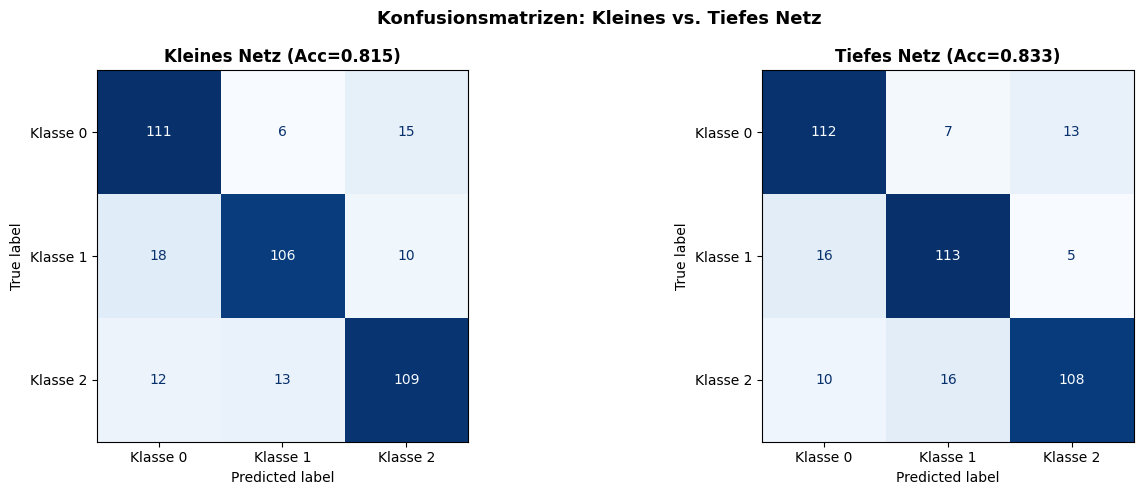

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_small, y_pred_deep],
    [f'Kleines Netz (Acc={acc_small:.3f})', f'Tiefes Netz (Acc={acc_deep:.3f})']
):
    cm_val = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm_val,
        display_labels=class_names
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Konfusionsmatrizen: Kleines vs. Tiefes Netz',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Fazit

- Ein tieferes Netz hat mehr **Modellkapazitaet** – messbar durch die Parameteranzahl.
- Auf einem komplexen Datensatz (20 Features, 3 Klassen, 2 Cluster)
  zeigt sich dieser Vorteil als **messbar hoehere Accuracy**.
- Die **Lernkurven (Train + Val)** zeigen mehr als die finale Accuracy:
  ein grosser Abstand zwischen beiden Kurven signalisiert Overfitting.
- **Mehr Kapazitaet hilft**, wenn Aufgabe komplex und genuegend Daten vorhanden.
- **Mehr Kapazitaet schadet**, wenn Datensatz zu klein –
  das Modell lernt Rauschen statt Struktur.
- **Datensatzgroesse:** Fuer aussagekraeftige Lernkurven braucht man
  mindestens ~300 Validierungssamples. Bei Iris (24 Val-Samples)
  sind die Kurven zu rauschig fuer diesen Vergleich.

> **Kernbotschaft:** Die richtige Modellgroesse haengt immer von
> Datensatzgroesse und Aufgabenkomplexitaet ab.
> Lernkurven sind das wichtigste Werkzeug zur Diagnose.


### Didaktische Bewertung


**1. Overfitting ist sichtbar** — Val-Loss steigt, während Train-Loss sinkt. Klarer geht es nicht.

**2. Overfitting bedeutet nicht automatisch "schlechter"** — Das overfittende Modell hat trotzdem eine höhere Test-Accuracy. Das ist eine wichtige Nuance: ein Modell kann overfitting zeigen und trotzdem das bessere Modell sein.

**3. Parameter und Accuracy skalieren nicht linear** — 9× mehr Parameter bringen nur 2.25% mehr Accuracy. Das motiviert direkt die nächste Frage:

> Kann man die Kapazität des tiefen Netzes behalten, aber das Overfitting reduzieren?

Die Antwort ist **Dropout** — und damit ist der Übergang zu K09_02 perfekt motiviert.